In [4]:
from qiskit_ibm_runtime import QiskitRuntimeService

QiskitRuntimeService.save_account(
token="<your-api-key>", # Use the 44-character API_KEY you created and saved from the IBM Quantum Platform Home dashboard
instance="<CRN>", # Optional
)

In [5]:
from qiskit_ibm_runtime import QiskitRuntimeService

# Run every time you need the service
service = QiskitRuntimeService()

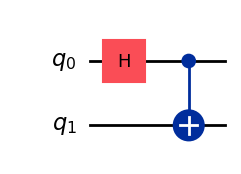

In [6]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp
from qiskit.transpiler import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import EstimatorOptions
from qiskit_ibm_runtime import EstimatorV2 as Estimator
from matplotlib import pyplot as plt
# Uncomment the next line if you want to use a simulator:
# from qiskit_ibm_runtime.fake_provider import FakeBelemV2


# Create a new circuit with two qubits
qc = QuantumCircuit(2)

# Add a Hadamard gate to qubit 0
qc.h(0)

# Perform a controlled-X gate on qubit 1, controlled by qubit 0
qc.cx(0, 1)

# Return a drawing of the circuit using MatPlotLib ("mpl").
# These guides are written by using Jupyter notebooks, which
# display the output of the last line of each cell.
# If you're running this in a script, use `print(qc.draw())` to
# print a text drawing.
qc.draw("mpl")

In [7]:
# Set up six different observables.

observables_labels = ["IZ", "IX", "ZI", "XI", "ZZ", "XX"]
observables = [SparsePauliOp(label) for label in observables_labels]

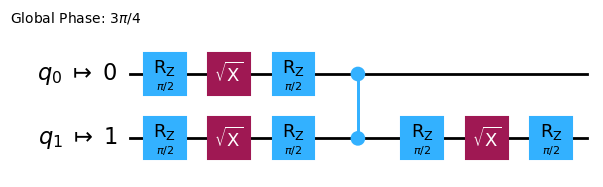

In [8]:
service = QiskitRuntimeService()

backend = service.least_busy(simulator=False, operational=True)

# Convert to an ISA circuit and layout-mapped observables.
pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
isa_circuit = pm.run(qc)

isa_circuit.draw("mpl", idle_wires=False)

In [9]:
# Construct the Estimator instance.

estimator = Estimator(mode=backend)
estimator.options.resilience_level = 1
estimator.options.default_shots = 5000

mapped_observables = [
    observable.apply_layout(isa_circuit.layout) for observable in observables
]

# One pub, with one circuit to run against five different observables.
job = estimator.run([(isa_circuit, mapped_observables)])

# Use the job ID to retrieve your job data later
print(f">>> Job ID: {job.job_id()}")

>>> Job ID: d7tusnaudops7398hfe0


### O problema acima foi rodado no chip físico real IBM_Marrakesh de 156-qubits, tipo de processador: Heron r2 (Heron processor).

In [14]:
# This is the result of the entire submission.  You submitted one Pub,
# so this contains one inner result (and some metadata of its own).
job_result = job.result()

# This is the result from our single pub, which had six observables,
# so contains information on all six.
pub_result = job.result()[0]

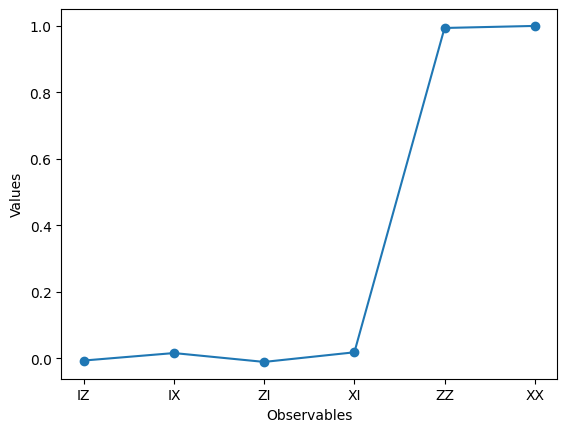

In [15]:
# Plot the result

values = pub_result.data.evs

errors = pub_result.data.stds

# plotting graph
plt.plot(observables_labels, values, "-o")
plt.xlabel("Observables")
plt.ylabel("Values")
plt.show()

## Alternative: run the example using a simulator - FAKE-DEVICE

FakeBelemV2 não é um chip quântico real, mas um backend simulado ("FAKE" provider) usado no Qiskit para análises e testes. Este fake-device imita o comportamento de um chip físico de 5-qubits.

Lançamento da Interface V2: O FakeBelemV2 foi introduzido como parte da transição do Qiskit para a interface BackendV2, consolidando-se amplamente em versões como o Qiskit 0.39 (lançado por volta de outubro de 2022).
Hardware Original: Ele é baseado no sistema real IBM Quantum Belem, um processador de 5 qubits da família Falcon que esteve ativo e disponível na nuvem principalmente entre 2020 e 2023.

Note que, como ele é um fake-device antigo de no mínimo 3 ou 4 anos atrás observamos a qualidade dos resultados são piores do que os rodados no chip quântico real, ibm_marrakesh, de 156-qubits.

T1, T2 e erros de operação são as variáveis de ruído que geralmente que se adota nos chips quânticos. 
Essas variáveis medem a qualidade e a estabilidade dos qubits. Em computação quântica, elas indicam quanto tempo a informação quântica sobrevive antes de ser destruída pelo ruído do ambiente(decoerência).

** Tempos de Coerência (Vida Útil):

(1) T1 = (Tempo de Relaxação Térmica).
É o tempo que um qubit leva para perder sua energia. Ou seja,
 o tempo de um qubit decair do estado excitado (|1>) para o estado fundamental (|0>).

(2) T2 = (Tempo de Dephasing):
É o tempo que o qubit mantém a sua fase quântica (a relação entre |0> e |1>). 
Geralmente é menor que o T1.

** Erros de Operação:

(1) Erro de Leitura (Readout Error):
A probabilidade do sistema medir "0" quando o qubit era "1" (ou vice-versa).
Ocorre devido a ruídos na eletrônica no momento de extrair o resultado.

(2) Erro de Porta (Gate Error):
A falha que ocorre ao aplicar um comando (como um "NOT" quântico).
Single-qubit error: Erro em comandos aplicados a um qubit isolado.
Two-qubit error (CNOT): Erro em interações entre dois qubits (geralmente muito mais alto que o de um qubit). 



In [16]:
# Use the following code instead if you want to run on a simulator:

from qiskit_ibm_runtime.fake_provider import FakeBelemV2
backend = FakeBelemV2()
estimator = Estimator(backend)

# Convert to an ISA circuit and layout-mapped observables.

pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
isa_circuit = pm.run(qc)
mapped_observables = [
    observable.apply_layout(isa_circuit.layout) for observable in observables
]

job = estimator.run([(isa_circuit, mapped_observables)])
result = job.result()

# This is the result of the entire submission.  You submitted one Pub,
# so this contains one inner result (and some metadata of its own).

job_result = job.result()

# This is the result from our single pub, which had five observables,
# so contains information on all five.

pub_result = job.result()[0]

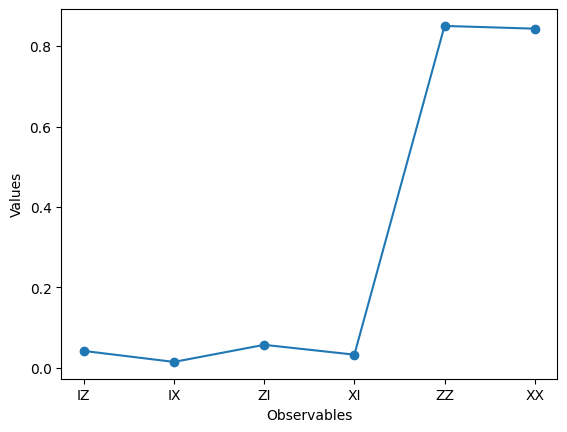

In [17]:
# Plot the result

values = pub_result.data.evs

errors = pub_result.data.stds

# plotting graph
plt.plot(observables_labels, values, "-o")
plt.xlabel("Observables")
plt.ylabel("Values")
plt.show()